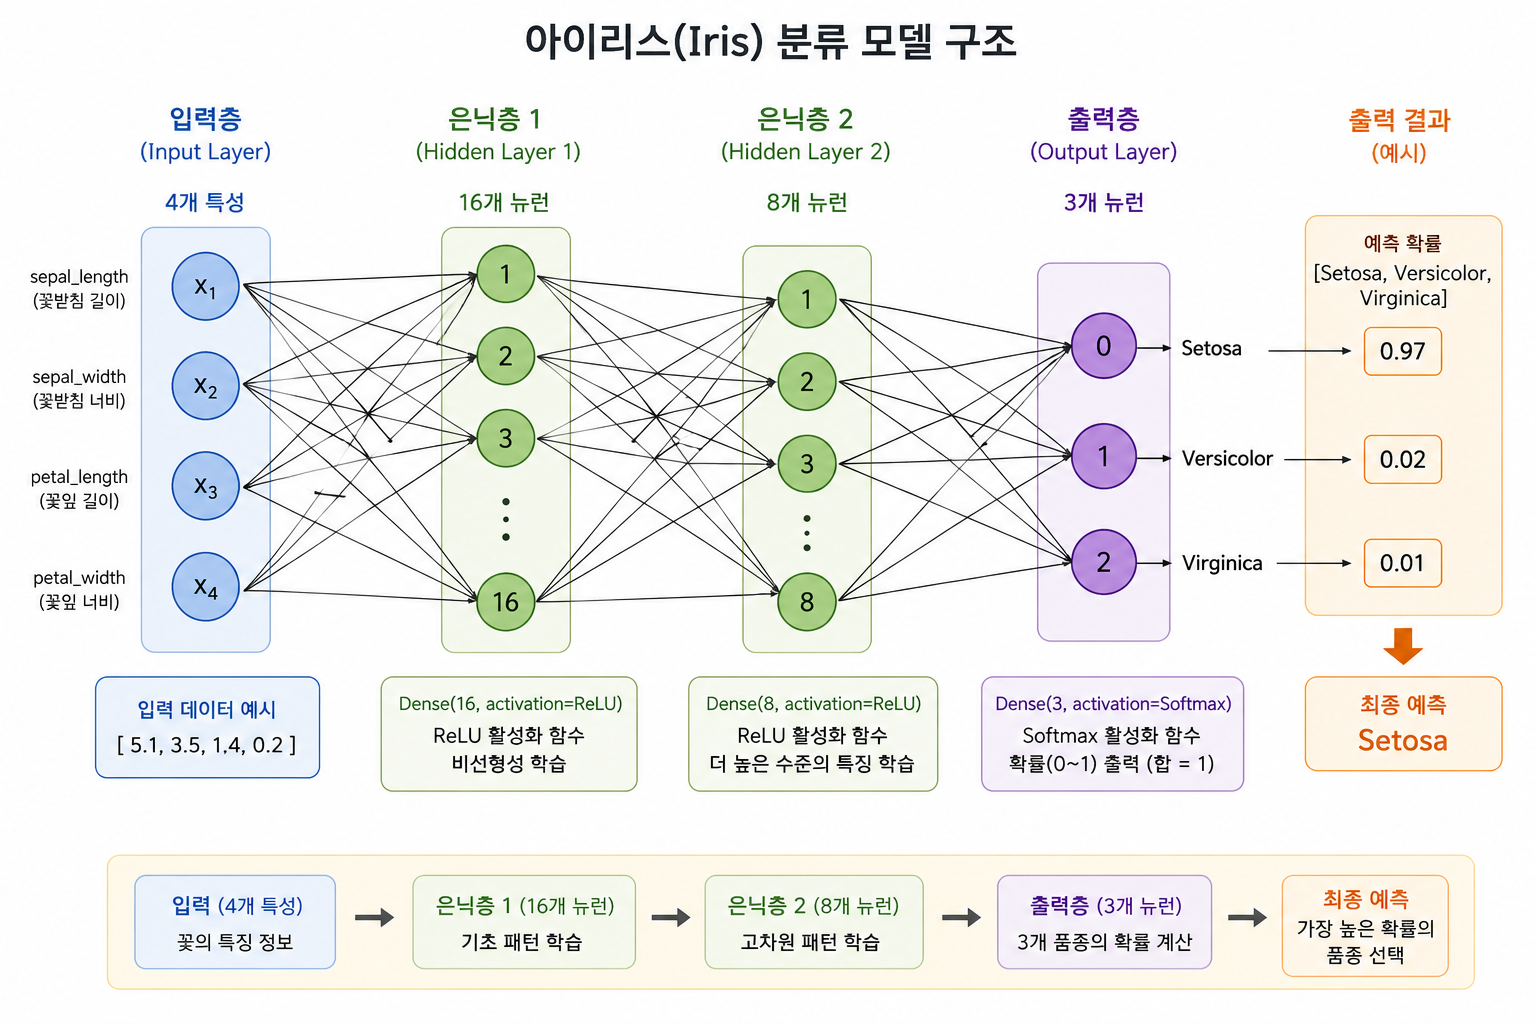

In [2]:
# 텐서플로 라이브러리 안에 있는 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense   

# 데이터를 다루는 데 필요한 라이브러리를 불러옵니다.
import numpy as np
import pandas as pd

(150, 4)
(150,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.2604 - loss: 1.1969 - val_accuracy: 0.4167 - val_loss: 1.1719
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2604 - loss: 1.1800 - val_accuracy: 0.3750 - val_loss: 1.1561
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2188 - loss: 1.1650 - val_accuracy: 0.3333 - val_loss: 1.1420
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1875 - loss: 1.1497 - val_accuracy: 0.2917 - val_loss: 1.1292
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1771 - loss: 1.1353 - val_accuracy: 0.2917 - val_loss: 1.1173
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1771 - loss: 1.1235 - val_accuracy: 0.2500 - val_loss: 1.1061
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1771 - loss: 1.1109 - val_accuracy: 0.2500 - val_loss: 1.0956
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1771 - loss: 1.1001 - val_accuracy: 0.2083 - val_loss

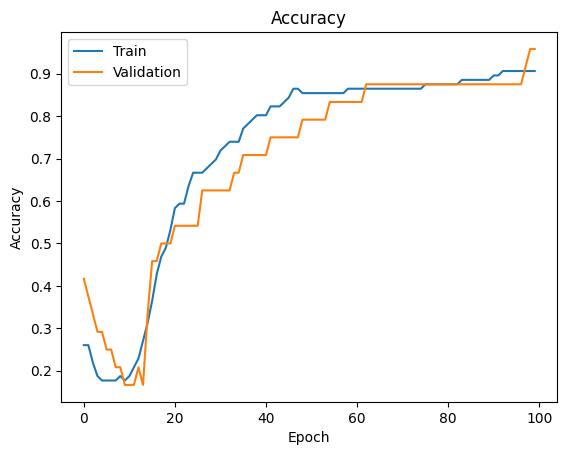

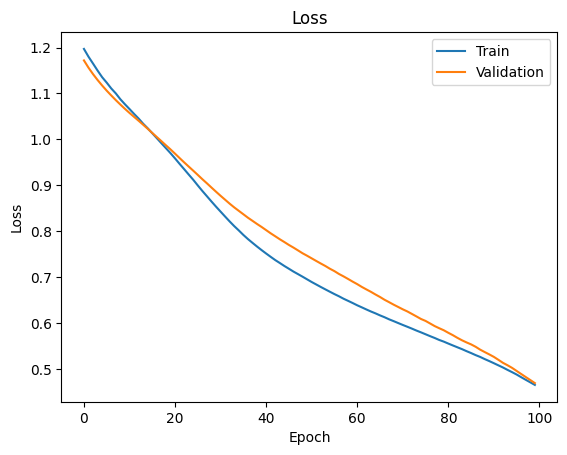

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

예측값
[0 2 1 1 0 2 0 0 2 2]

실제값
[0 2 1 1 0 1 0 0 2 1]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

예측 클래스 : 0
확률 : [[0.49 0.32 0.19]]

Setosa


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense, Input

# ==========================
# 1. 데이터 로드
# ==========================

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

# ==========================
# 2. 학습/테스트 분리
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# 3. 표준화
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# 4. 모델 생성
# ==========================

model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation="relu", name="Dense_1"),
    Dense(8, activation="relu", name="Dense_2"),
    Dense(3, activation="softmax", name="Output")
])

model.summary()

# ==========================
# 5. 컴파일
# ==========================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================
# 6. 학습
# ==========================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

# ==========================
# 7. 평가
# ==========================

loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print()
print("테스트 정확도 :", round(acc, 4))

# ==========================
# 8. 정확도 그래프
# ==========================

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# ==========================
# 9. Loss 그래프
# ==========================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# ==========================
# 10. 예측
# ==========================

pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

print()
print("예측값")
print(pred_class[:10])

print()
print("실제값")
print(y_test[:10])

# ==========================
# 11. 새로운 꽃 예측
# ==========================

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower = scaler.transform(
    new_flower
)

pred = model.predict(new_flower)

species = np.argmax(pred)

print()
print("예측 클래스 :", species)

print("확률 :", np.round(pred, 2))

print()

if species == 0:
    print("Setosa")
elif species == 1:
    print("Versicolor")
else:
    print("Virginica")